Завдання 2


1. Використовуючи датасет diabetes_data.csv створити модель на базі глибокої нейронної мережі для класифікування даних.
2. Розбити датасет на 3 підвибірки: тренувальний (70%), валідаційний (20%), тестовий (10%), використовучі власну функцію, або функції які реалізовані в pandas чи sklearn.
3. Дослідити як впливає скейлінг і нормалізація даних на результат моделі https://scikit-learn.org/stable/modules/preprocessing.html
4. Імплементувати модель в Keras за допомогою Sequentinal(). Обгрунтувати обрання кількості нейронів та шарів. Провести
дослідження, як буде мінятися точність мережі при різних гіперпараметрах.
5. В якості оптимізатора застосувати декілька алгоритмів навчання (https://keras.io/api/optimizers/ ):
    - SGD
    - RMSprop
    - Adam
    - Adadelta
    - Adagrad
    - Adamax
    - Nadam
6. Використати різні активаційні функції і виявити вплив виду функції та точність моделі.
7. Побудувати графіки навчання по кожному оптимізатору і порівняти швидкість збіжності алгоритмів.
8. Провести тестування мережі. Визначити чи не було перенавчання мережі.

All the imports in one place

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
from tensorflow.python.keras.utils.np_utils import to_categorical

Load the data for the regression

In [2]:
#read in data using pandas
train_df = pd.read_csv('../data/lab1/diabetes_data.csv')
#check data has been read in properly
train_df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
train_df.shape

(768, 9)

In [4]:
train_df.describe(include='all')

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
train_df.isna().sum()

pregnancies    0
glucose        0
diastolic      0
triceps        0
insulin        0
bmi            0
dpf            0
age            0
diabetes       0
dtype: int64

Split data into training features and feature to predict

In [6]:
y = train_df['diabetes']
train_df = train_df.drop('diabetes', axis=1)
X = train_df

In [7]:
y = to_categorical(y)
y

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]], shape=(768, 2), dtype=float32)

In [8]:
X.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


Split the data into training, validation and test datasets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
  X,y, random_state=42, test_size=0.3, shuffle=True, stratify=y)

In [11]:
X_test, X_val, y_test, y_val = train_test_split(
  X_test,y_test, random_state=42, test_size=0.33, shuffle=True, stratify=y_test)

Do data scaling for better results

In [12]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)
y_val = y_scaler.transform(y_val)

In [13]:
X_train

array([[ 5.01620750e-02,  4.10635497e-02, -4.25056642e-01, ...,
        -3.81311121e-03, -7.17608963e-01,  1.64529214e-01],
       [-2.39483455e-01,  1.50490950e+00, -3.17743329e-01, ...,
         3.10242214e-01, -3.29217522e-01, -2.55795182e-01],
       [ 2.07768078e+00,  1.03772462e+00,  3.26136549e-01, ...,
         1.59495658e-01,  2.64944607e+00,  1.50956728e+00],
       ...,
       [-5.29128984e-01,  1.96791842e-01, -3.17743329e-01, ...,
         1.00116393e+00,  1.89656420e+00, -7.60184457e-01],
       [ 6.29453134e-01, -9.55597521e-01, -3.75176934e+00, ...,
        -2.80181798e-01,  1.03988317e-01, -1.71730303e-01],
       [-1.10842004e+00,  1.81636608e+00,  4.33449862e-01, ...,
         3.43823326e+00,  5.83724352e+00, -6.76119578e-01]],
      shape=(537, 8))

In [14]:
y_train

array([[-1.3680855 ,  1.3680855 ],
       [-1.3680855 ,  1.3680855 ],
       [-1.3680855 ,  1.3680855 ],
       ...,
       [ 0.73094845, -0.73094845],
       [ 0.73094845, -0.73094845],
       [-1.3680855 ,  1.3680855 ]], shape=(537, 2), dtype=float32)

Create model

In [15]:
def build_model(train, activator='relu', optimizer='adam', layers=2, neurons=64, loss='binary_crossentropy', metrics=['accuracy']):

  model = Sequential()
  n_cols = train.shape[1]

  model.add(Input(shape=(n_cols,)))

  model.add(Dense(neurons, activation=activator))
  for i in range(layers-1):
      model.add(Dense(neurons, activation=activator))
  model.add(Dense(2, activation='softmax'))

  model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
  return model

In [16]:
def get_metrics(test_y, y_pred):
    # Convert one-hot encoded true values to class labels
    y_true = np.argmax(test_y, axis=1)

    # Convert probability predictions to class labels
    y_pred_labels = np.argmax(y_pred, axis=1)

    # For binary classification, get probability of positive class (class 1)
    # This is needed for ROC-AUC and average precision
    y_pred_proba_positive = y_pred[:, 1]

    metrics = [
        round(accuracy_score(y_true, y_pred_labels), 3),
        round(precision_score(y_true, y_pred_labels, average='binary'), 3),  # for binary
        round(recall_score(y_true, y_pred_labels, average='binary'), 3),  # for binary
        round(f1_score(y_true, y_pred_labels, average='binary'), 3),  # for binary
    ]

    return metrics

Try different optimizers in models

In [17]:
optimizers = ['adam', 'rmsprop', 'sgd', 'adadelta', 'adagrad', 'adamax', 'nadam']
activators = ['relu', 'tanh', 'sigmoid', 'softmax', 'silu', 'elu', 'gelu']

models_opt_act = []
metrics_opt_act = []

histories = []
predictions = []

for opt in optimizers:
    models = []
    pred = []
    hists = []
    metr = []
    for act in activators:

        model = build_model(X_train, optimizer=opt, activator=act, layers=3, neurons=128)
        models.append(model)

        early_stopping_monitor = EarlyStopping(patience=3)
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        hists.append(history.history)

        test_y_predictions = model.predict(X_test)
        pred.append(test_y_predictions)

        test_y_predictions = model.predict(X_test)
        new_metrics = get_metrics(y_test, test_y_predictions)
        metr.append(new_metrics)

    models_opt_act = models
    histories.append(hists)
    predictions.append(pred)
    metrics_opt_act.append(metr)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━

C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


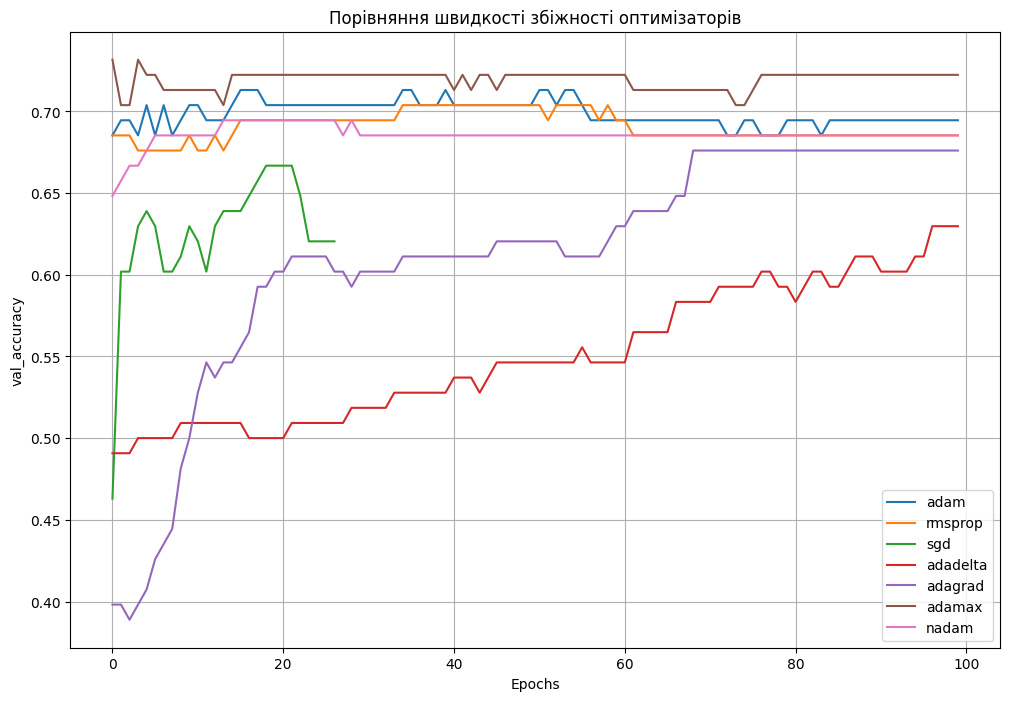

In [18]:
plt.style.use('default')
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final loss matrix
val_acc = []
final_loss_matrix = np.zeros((len(optimizers), len(activators)))

for opt_idx, (opt, history) in enumerate(zip(optimizers, histories)):
    plt.plot(history[0]['val_accuracy'], label=opt)

    for act_idx in range(len(activators)):
        loss_curve = history[act_idx]['val_accuracy']
        val_acc.append(loss_curve)
        # Store final loss value
        final_loss_matrix[opt_idx, act_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності оптимізаторів')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

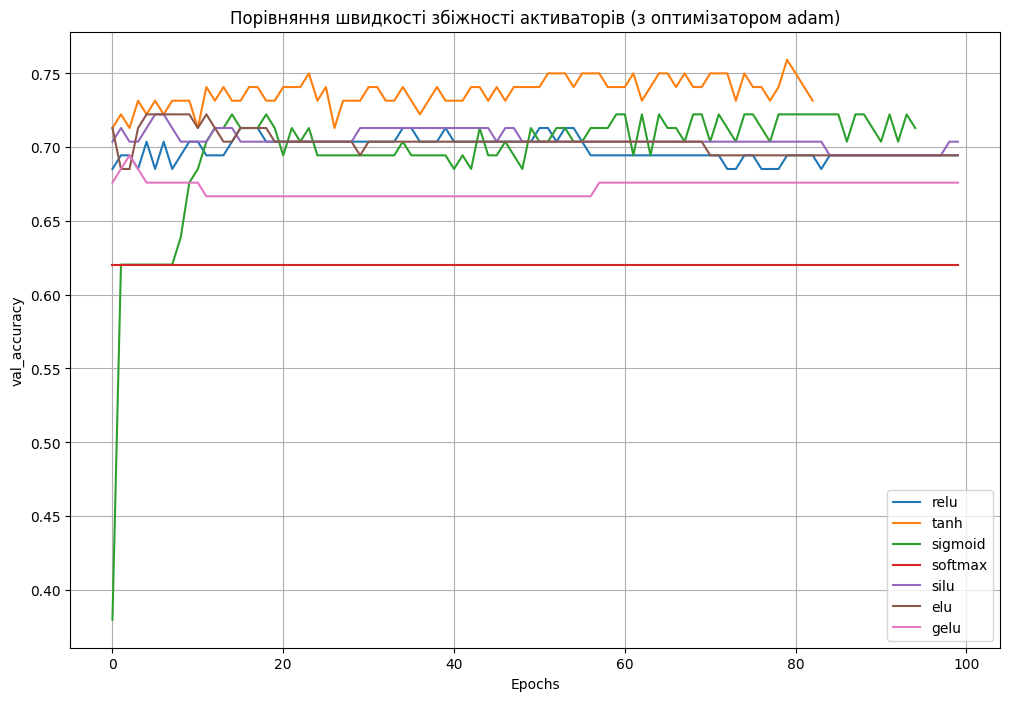

In [19]:
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final loss matrix
val_acc = []
final_loss_matrix = np.zeros((len(activators), len(optimizers)))

for act_idx, act in enumerate(activators):
    # Для кожного активатора беремо першу модель (з оптимізатором 'adam')
    history_for_act = histories[0][act_idx]  # histories[0] - це для 'adam' оптимізатора
    plt.plot(history_for_act['val_accuracy'], label=act)

    for opt_idx in range(len(optimizers)):
        loss_curve = histories[opt_idx][act_idx]['val_accuracy']
        val_acc.append(loss_curve)
        # Store final loss value
        final_loss_matrix[act_idx, opt_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності активаторів (з оптимізатором adam)')
plt.xlabel('Epochs')
plt.ylabel('val_accuracy')
plt.legend()
plt.grid(True)
plt.show()

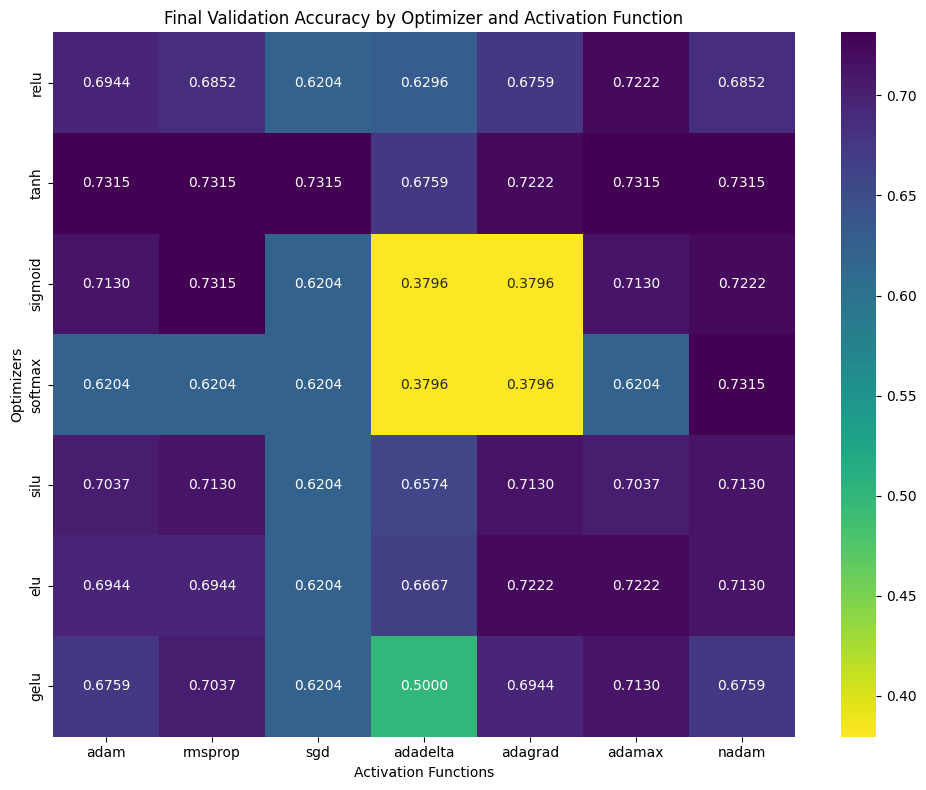

In [20]:
# Plot heatmap of final loss values
plt.figure(figsize=(10, 8))
sns.heatmap(final_loss_matrix,
            xticklabels=optimizers,
            yticklabels=activators,
            annot=True,
            fmt='.4f',
            cmap='viridis_r')
plt.title('Final Validation Accuracy by Optimizer and Activation Function')
plt.xlabel('Activation Functions')
plt.ylabel('Optimizers')
plt.tight_layout()
plt.show()

In [21]:
best_act_idx, best_opt_idx = np.unravel_index(np.argmin(final_loss_matrix), final_loss_matrix.shape)
print(f"Best combination: Activator = {activators[best_act_idx]}, Optimizer = {optimizers[best_opt_idx]}")
print(f"Most final val_accuracy: {final_loss_matrix[best_act_idx, best_opt_idx]:.4f}")

print("\nSorted combinations by val_accuracy:")
combinations = []
for act_idx, act in enumerate(activators):
    for opt_idx, opt in enumerate(optimizers):
        combinations.append((act, opt, final_loss_matrix[act_idx, opt_idx]))

combinations.sort(key=lambda x: x[2], reverse=True)
for act, opt, loss in combinations[:10]:  # Топ-10
    print(f"{act:8} + {opt:10}: {loss:.4f}")

Best combination: Activator = sigmoid, Optimizer = adadelta
Most final val_accuracy: 0.3796

Sorted combinations by val_accuracy:
tanh     + adam      : 0.7315
tanh     + rmsprop   : 0.7315
tanh     + sgd       : 0.7315
tanh     + adamax    : 0.7315
tanh     + nadam     : 0.7315
sigmoid  + rmsprop   : 0.7315
softmax  + nadam     : 0.7315
relu     + adamax    : 0.7222
tanh     + adagrad   : 0.7222
sigmoid  + nadam     : 0.7222


In [22]:
layers = [2, 3, 4, 5, 6]
neurons = [6, 7, 9, 10, 16, 32, 64, 128, 256, 512]
models_diff_lay_neur = []

for l in layers :
    models = []
    for n in neurons :
        model = build_model(X_train, neurons=n, layers=l)
        models.append(model)
    models_diff_lay_neur.append(models)

metrics_diff_lay_neur = []

early_stopping_monitor = EarlyStopping(patience=3)

for layer_models in models_diff_lay_neur:
    layer_metrics = []
    for model in layer_models:
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        test_y_predictions = model.predict(X_test, verbose=0)
        new_metrics = get_metrics(y_test, test_y_predictions)
        layer_metrics.append(new_metrics)
    metrics_diff_lay_neur.append(layer_metrics)


df = pd.DataFrame(metrics_diff_lay_neur,
                  index=[f'{l} layers' for l in layers],
                  columns=[f'{n} neurons.' for n in neurons])

print('accuracy, precision, recall, f1 score')
df

C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\PycharmProjects\DL-Labs\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


accuracy, precision, recall, f1 score


,6 neurons.,7 neurons.,9 neurons.,10 neurons.,16 neurons.,32 neurons.,64 neurons.,128 neurons.,256 neurons.,512 neurons.
2 layers,"[0.688, 0.554, 0.574, 0.564]","[0.481, 0.38, 0.759, 0.506]","[0.584, 0.438, 0.648, 0.522]","[0.468, 0.387, 0.889, 0.539]","[0.519, 0.391, 0.667, 0.493]","[0.662, 0.514, 0.667, 0.581]","[0.695, 0.543, 0.815, 0.652]","[0.662, 0.514, 0.685, 0.587]","[0.682, 0.532, 0.759, 0.626]","[0.662, 0.514, 0.685, 0.587]"
3 layers,"[0.649, 0.0, 0.0, 0.0]","[0.351, 0.351, 1.0, 0.519]","[0.578, 0.446, 0.833, 0.581]","[0.688, 0.571, 0.444, 0.5]","[0.682, 0.778, 0.13, 0.222]","[0.701, 0.562, 0.667, 0.61]","[0.662, 0.512, 0.778, 0.618]","[0.688, 0.547, 0.648, 0.593]","[0.682, 0.529, 0.833, 0.647]","[0.682, 0.532, 0.778, 0.632]"
4 layers,"[0.37, 0.348, 0.907, 0.503]","[0.448, 0.363, 0.759, 0.491]","[0.351, 0.351, 1.0, 0.519]","[0.643, 0.492, 0.537, 0.513]","[0.351, 0.351, 1.0, 0.519]","[0.74, 0.675, 0.5, 0.574]","[0.649, 0.5, 0.704, 0.585]","[0.662, 0.511, 0.833, 0.634]","[0.643, 0.495, 0.907, 0.641]","[0.675, 0.523, 0.852, 0.648]"
5 layers,"[0.539, 0.429, 0.944, 0.59]","[0.468, 0.391, 0.926, 0.549]","[0.675, 0.533, 0.593, 0.561]","[0.37, 0.356, 0.981, 0.522]","[0.649, 0.5, 0.037, 0.069]","[0.708, 0.569, 0.685, 0.622]","[0.532, 0.425, 0.944, 0.586]","[0.63, 0.485, 0.926, 0.637]","[0.656, 0.505, 0.87, 0.639]","[0.662, 0.511, 0.87, 0.644]"
6 layers,"[0.351, 0.351, 1.0, 0.519]","[0.649, 0.0, 0.0, 0.0]","[0.351, 0.351, 1.0, 0.519]","[0.357, 0.351, 0.981, 0.517]","[0.649, 0.0, 0.0, 0.0]","[0.695, 0.543, 0.815, 0.652]","[0.675, 0.526, 0.759, 0.621]","[0.474, 0.397, 0.963, 0.562]","[0.656, 0.505, 0.889, 0.644]","[0.578, 0.452, 0.963, 0.615]"


№   Layers   Neurons    Accuracy Precision Recall   F1      
--------------------------------------------------
1   4        32         0.74     0.675    0.5      0.574   
2   5        32         0.708    0.569    0.685    0.622   
3   3        32         0.701    0.562    0.667    0.61    
4   6        32         0.695    0.543    0.815    0.652   
5   2        64         0.695    0.543    0.815    0.652   
6   3        128        0.688    0.547    0.648    0.593   
7   3        10         0.688    0.571    0.444    0.5     
8   2        6          0.688    0.554    0.574    0.564   
9   3        512        0.682    0.532    0.778    0.632   
10  3        256        0.682    0.529    0.833    0.647   


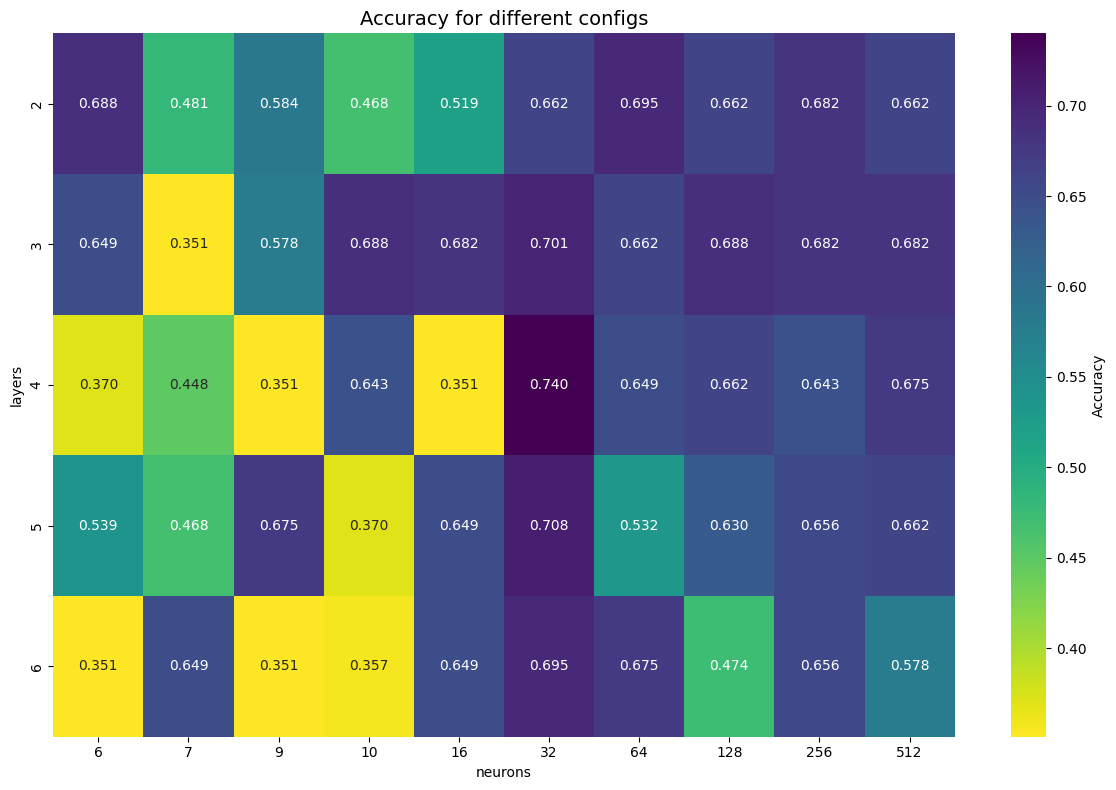

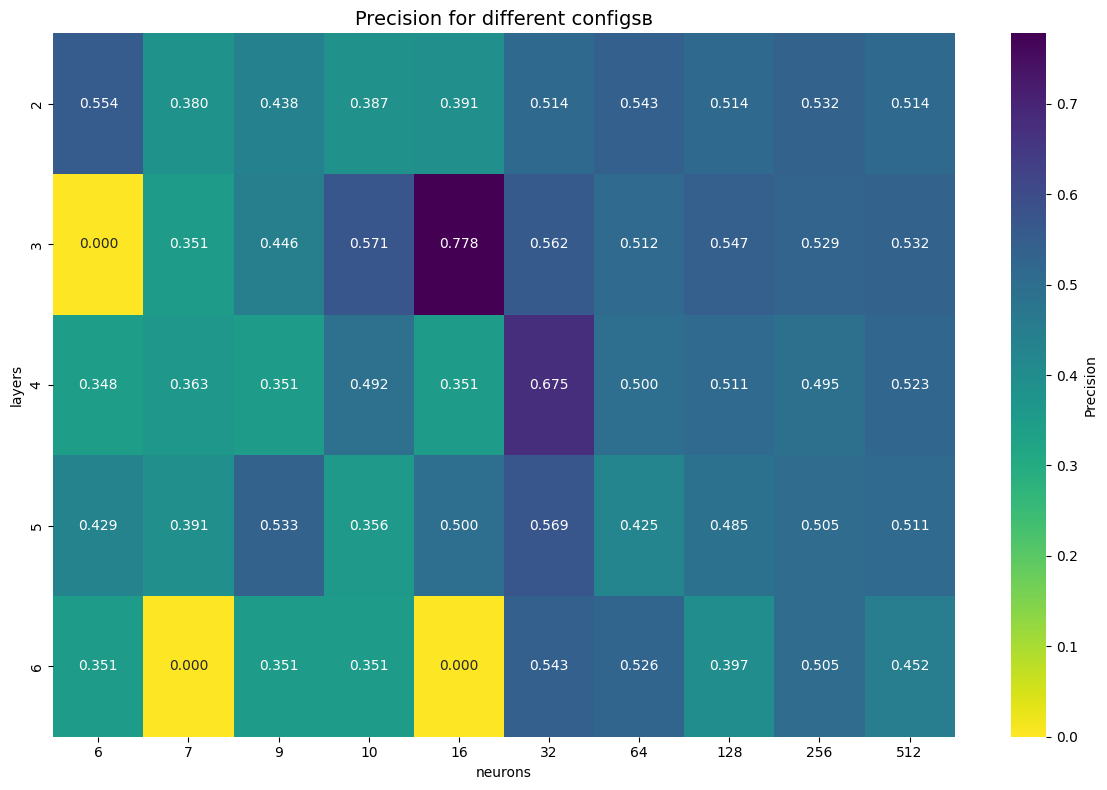

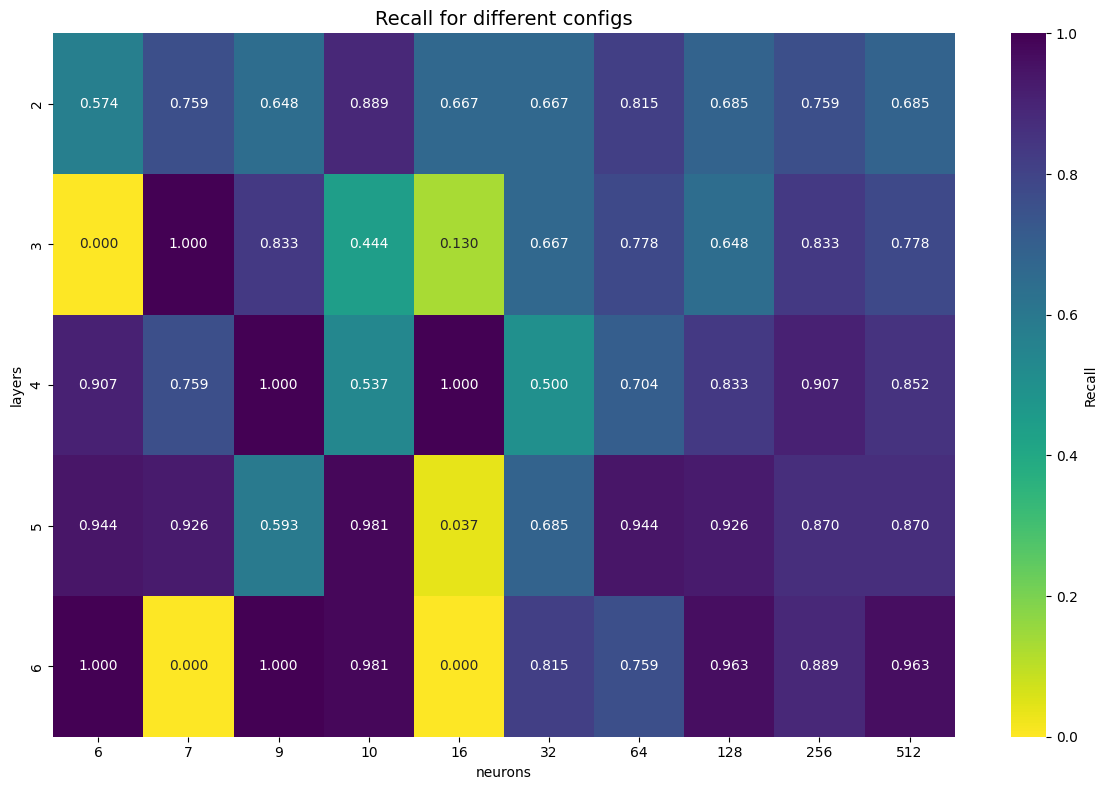

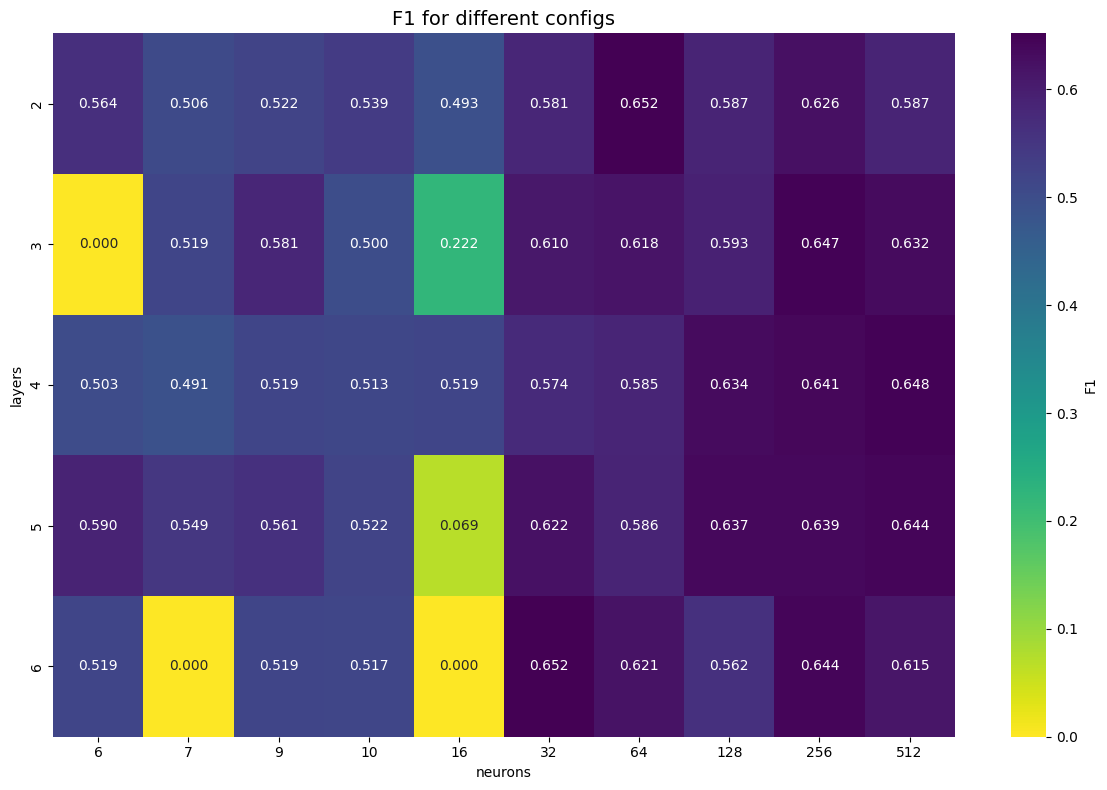

In [23]:
plt.style.use('default')
all_results = []
for i, l in enumerate(layers):
    for j, n in enumerate(neurons):
        accuracy, precision, recall, f1 = metrics_diff_lay_neur[i][j]
        all_results.append((accuracy, l, n, precision, recall, f1))

top_10 = sorted(all_results, reverse=True)[:10]

print(f"{'№':<3} {'Layers':<8} {'Neurons':<10} {'Accuracy':<8} {'Precision':<8} {'Recall':<8} {'F1':<8}")
print("-" * 50)

for i, (accuracy, l, n, precision, recall, f1) in enumerate(top_10, 1):
    print(f"{i:<3} {l:<8} {n:<10} {accuracy:<8} {precision:<8} {recall:<8} {f1:<8}")


# heatmap by Accuracy matrix
accuracy_matrix = np.array([[metrics_diff_lay_neur[i][j][0]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(accuracy_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'Accuracy'}
            )
plt.title('Accuracy for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by Precision matrix
precision_matrix = np.array([[metrics_diff_lay_neur[i][j][1]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(precision_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'Precision'}
            )
plt.title('Precision for different configsв', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by Recall matrix
recall_matrix = np.array([[metrics_diff_lay_neur[i][j][2]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(recall_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'Recall'}
            )
plt.title('Recall for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by F1 matrix
f1_matrix = np.array([[metrics_diff_lay_neur[i][j][3]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(f1_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'F1'}
            )
plt.title('F1 for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

So basic option adam+relu is working good for this task, so next experiments will be done using this combination

Check for overfitting

In [24]:
model_new = build_model(X_train, optimizer='adam', activator='tanh', layers=3, neurons=128)
early_stopping_monitor = EarlyStopping(patience=3)
model_new.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stopping_monitor],
    verbose=0
)

y_predictions_test = model_new.predict(X_test)
y_predictions_train = model_new.predict(X_train)
test_metrics = get_metrics(y_test, y_predictions_test)
train_metrics = get_metrics(y_train, y_predictions_train)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [25]:
print('train')
print('Accuracy\tPrecision\t\tRecall\t\tF1')
print('%.3f' % train_metrics[0], '\t\t%.3f\t' % train_metrics[1], '\t%.3f\t' % train_metrics[2], '\t%.3f\t' % train_metrics[3])

print('test')
print('Accuracy\tPrecision\t\tRecall\t\tF1')
print('%.3f' % test_metrics[0], '\t\t%.3f\t' % test_metrics[1], '\t%.3f\t' % test_metrics[2], '\t%.3f\t' % test_metrics[3])

train
Accuracy	Precision		Recall		F1
0.834 		0.750	 	0.786	 	0.768	
test
Accuracy	Precision		Recall		F1
0.727 		0.625	 	0.556	 	0.588	
